# SMACNP Training: PeakWeather Context → MeteoSwiss Targets at Station Locations

This notebook trains an SMACNP model using PeakWeather (PW) station readings as **context** and MeteoSwiss (MS) reference observations at the same station coordinates as **training target**.

## Setup

| | |
|---|---|
| **Context** | 103 PW train stations — (lon, lat, elev, mTPI, cos_doy, sin_doy) + T_obs |
| **Target (val loss)** | MeteoSwiss temperature at 34 PW val-station locations |
| **Station split** | 60 / 20 / 20 → 103 train / 34 val / 35 test from 172 valid PW stations (≥ 99% availability, 2017–2024) |
| **Temporal split** | 5-fold cross-validation over 2017–2024 (2921 days) |
| **Temperature** | Daily mean |
| **Normalization** | MeteoSwiss train-station statistics applied to both context (PW) and target (MS) |

## Key design choices

- **MeteoSwiss as target:** Training the loss against MS measurements (the official Swiss reference dataset) rather than the raw PW readings ensures that the model's predictions are calibrated to the higher-quality standard, at the cost of needing to load both datasets.
- **PeakWeather as context:** PW provides GPS-precise point measurements at diverse altitudes across Switzerland, making it a rich irregular-grid input for the SMACNP encoder — in contrast to ERA5 which averages over ~10×10 km cells.
- **Normalization consistency:** A single normalization (MS train-station mean/std) is applied to both PW context values and MS target values, keeping both sources on the same scale and avoiding any systematic offset.
- **Same spatial footprint:** Both context and target share PW station coordinates, so the model is not asked to extrapolate to new spatial regions — only to infer MS-equivalent values from PW observations at nearby locations.

## Companion notebook

Use **predictions_pw.ipynb** (with `MODEL_NAME` pointing to this run's `TRIAL_NAME`) to evaluate the trained model on the 35 held-out PW test stations.


In [1]:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import params

params.configure_renku_cuda()
device = params.select_device()
print(f'Using device: {device}')

/home/renku/work/convNPClimate/params.py:94: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (not (not self.SEASONAL_FEATURES and self.SEASONAL_FEATURES_IN_MLP),


Using device: cuda


In [3]:
# Training configuration - modify these parameters as needed
TEMPERATURE_TYPE = 'mean'
PW_FIRST_DATE = '2017-01-01'
PW_LAST_DATE  = '2024-12-31'
PW_VALIDITY_THRESHOLD = 0.99

PARAMS = params.Params(
    VARIABLE='tmax',
    TEMPERATURE_TYPE=TEMPERATURE_TYPE,
    MODEL_TYPE='smacnp',
    CONTEXT_TYPE='peakweather',
    PW_TRAIN_FRAC=0.8,
    PW_VAL_FRAC=0.0,
    STATION_SPLIT_SEED=42,
    N_EPOCHS=100,
    PATIENCE=30,
    N_FOLDS=5,
    TRIAL_NAME='test-100e-ms-pw-stations-mean-4',
    RUN_TYPE='cloud' if params.is_renku() else 'local',
    BATCH_SIZE=8 if params.is_renku() else 16,
    DEVICE=device,
    SEASONAL_FEATURES=True,
    # SMACNP architecture
    R_DIM=128,
    W_DIM=128,
    V_DIM=128,
    N_HEADS=4,
    SMACNP_HIDDEN=128,
    NUM_LAYERS_MLP=2,
    USE_PE=True,
    PE_DIM=32,
)

print(f"Configuration: {PARAMS}")

Configuration: Params(VARIABLE='tmax', DATA_YEAR_START=2023, TEMPERATURE_TYPE='mean', SEASONAL_FEATURES=True, SEASONAL_FEATURES_IN_MLP=True, USE_ELEVATION=True, USE_MTPI=True, N_CHANNELS=128, N_BLOCKS=6, KERNEL_SIZE=5, LENGTH_SCALE=0.1, IN_CHANNELS=0, N_EPOCHS=100, BATCH_SIZE=8, LR=0.0005, PATIENCE=30, LOSS_FN='gll', N_FOLDS=5, SEED=42, TRIAL_NAME='test-100e-ms-pw-stations-mean-4', RUN_TYPE='cloud', DEVICE=device(type='cuda'), ERA5_MAX_TEMP_GLOB=None, ERA5_GEOPOTENTIAL_GLOB=None, METEO_SWISS_MAX_TEMP_GLOB=None, ERA5_MEAN_TEMP_GLOB=None, METEO_SWISS_MEAN_TEMP_GLOB=None, HI_RES_TOPOGRAPHY_ZARR_PATH=None, MODEL_TYPE='smacnp', R_DIM=128, W_DIM=128, V_DIM=128, N_HEADS=4, SMACNP_HIDDEN=128, NUM_LAYERS_MLP=2, USE_PE=True, PE_DIM=32, PW_TRAIN_FRAC=0.8, PW_VAL_FRAC=0.0, STATION_SPLIT_SEED=42, CONTEXT_TYPE='peakweather')


In [4]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.optim as optim

import datasets as ds
import model_factory
import cloud_sync
import visualization as vis
from convCNP.training.training_elev import train_smacnp

/home/renku/work/.venv/lib/python3.13/site-packages/dirsync/syncer.py:104: SyntaxWarning: invalid escape sequence '\.'
  self._exclude.append('^\.dirsync$')


In [5]:
# Define all paths as local - these are where data will be read from
BASE_DIR = Path('.')
OUTPUT_DIR = BASE_DIR / 'trained_models' / PARAMS.TRIAL_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BASE_DATASET_DIR = BASE_DIR / 'datasets'
REMOTE_OUTPUT_DIR = Path().cwd() / '..' / 'trained-models-mount' / PARAMS.TRIAL_NAME
REMOTE_DATASET_DIR = Path().cwd() / '..' / 'datasets-mount'

# Note: loading datasets on Renkulab directly from Polybox was no working well.
# Things do work if we first sync the files over to local storage and then load them
# locally.
cloud_sync.sync_from_cloud_if_needed(REMOTE_DATASET_DIR, BASE_DATASET_DIR, PARAMS.RUN_TYPE)

# Save data paths in params for reproducibility (used by predictions notebook)
PARAMS = PARAMS.with_data_paths(ds.build_data_paths(BASE_DATASET_DIR))

Cloud run detected. Syncing data from /home/renku/work/convNPClimate/../datasets-mount to datasets...
Synchronizing directory datasets with /home/renku/work/convNPClimate/../datasets-mount
Source directory: /home/renku/work/convNPClimate/../datasets-mount:
dirsync finished in 2.20 seconds.
28 directories parsed, 0 files copied

Dataset sync complete.


In [6]:
# Load PeakWeather stations (all valid stations, before split)
daily_tmean_pw, stations_meta, valid_stations = ds.load_peakweather_stations(
    first_date=PW_FIRST_DATE,
    last_date=PW_LAST_DATE,
    validity_threshold=PW_VALIDITY_THRESHOLD,
    aggregation_method='mean',
)
daily_tmean_pw.index = daily_tmean_pw.index - pd.Timedelta(days=1)
pw_dates_pd = pd.DatetimeIndex(daily_tmean_pw.index.date.astype(str))

# Seasonal features from PW time axis
pw_times_np = np.array(pw_dates_pd, dtype='datetime64[D]')
if PARAMS.SEASONAL_FEATURES:
    seasonal_features = ds.compute_seasonal_features(pw_times_np, device=device)
    print(f"Seasonal features shape: {seasonal_features.shape}")
else:
    seasonal_features = None


Loading PeakWeather stations (None) from 2017-01-01 to 2024-12-31 ...
  172 / 302 stations pass validity threshold (99%)
  Daily tmax shape: (2921, 172)  (2017-01-01 → 2024-12-30)
  Altitude range: [203, 3571] m
Computed seasonal features: torch.Size([2921, 2]), dtype: torch.float32
Seasonal features shape: torch.Size([2921, 2])


In [7]:
train_stations, val_stations, test_stations = ds.split_peakweather_stations(
    valid_stations,
    train_frac=PARAMS.PW_TRAIN_FRAC,
    val_frac=PARAMS.PW_VAL_FRAC,
    seed=PARAMS.STATION_SPLIT_SEED,
)

Station split: 137 train / 0 val / 35 test


In [8]:
daily_tmean_ms = ds.extract_meteoswiss_at_pw_stations(
    ms_glob=PARAMS.METEO_SWISS_MEAN_TEMP_GLOB,
    var_name='TabsD',
    stations_meta=stations_meta,
    station_ids=valid_stations,
)

print(f"MeteoSwiss-at-stations shape: {daily_tmean_ms.shape}")
print(f"Date range: {daily_tmean_ms.index[0].date()} → {daily_tmean_ms.index[-1].date()}")

/home/renku/work/convNPClimate/datasets.py:1310: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ms_ds = xr.open_mfdataset(str(ms_glob), combine='by_coords')


MeteoSwiss-at-stations shape: (4383, 172)
Date range: 2012-01-01 → 2023-12-31


In [9]:
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(PARAMS.HI_RES_TOPOGRAPHY_ZARR_PATH)

Loading high-resolution topography from Zarr: datasets/topo_subset.zarr
Topography dataset dimensions: FrozenMappingWarningOnValuesAccess({'y': 12800, 'x': 14200})
DEM shape: (12800, 14200), dtype: int16
TPI (TPI_500M) shape: (12800, 14200), dtype: float32


In [10]:
# Use MeteoSwiss values (not raw PW) as the normalization reference,
# since MeteoSwiss is what the model will be trained to predict.
ms_metadata = ds.compute_pw_metadata(daily_tmean_ms, train_stations)
print(f"MeteoSwiss metadata: mean={ms_metadata.data_mean:.2f} K, std={ms_metadata.data_std:.2f} K")


PW train stats: mean=280.66 K, std=8.05 K
MeteoSwiss metadata: mean=280.66 K, std=8.05 K


In [11]:
pw_times_np = np.array(pw_dates_pd, dtype='datetime64[D]')
seasonal_features = ds.compute_seasonal_features(pw_times_np, device=device)

# Pool: all 137 train+val PW station locations + PW readings (what the model sees as context)
x_pool, y_context_pool = ds.build_pw_station_tensors(
    daily_tmax=daily_tmean_pw,            # PW readings — context source
    station_ids=train_stations,
    stations_meta=stations_meta,
    hi_res_tpi=hi_res_tpi,
    metadata=ms_metadata,
    seasonal_features=seasonal_features,
    dates_pd=pw_dates_pd,
    device=device,
)
y_context_pool = y_context_pool.unsqueeze(-1)
y_context_pool = torch.nan_to_num(y_context_pool, nan=0.0)

_, y_target_pool = ds.build_pw_station_tensors(
    daily_tmax=daily_tmean_ms,
    station_ids=train_stations,
    stations_meta=stations_meta,
    hi_res_tpi=hi_res_tpi,
    metadata=ms_metadata,
    seasonal_features=seasonal_features,
    dates_pd=pw_dates_pd,
    device=device,
)
print(f"y_target_pool:   {y_target_pool.shape}  # (T, 137) — MS readings")



Computed seasonal features: torch.Size([2921, 2]), dtype: torch.float32
y_target_pool:   torch.Size([2921, 137])  # (T, 137) — MS readings


In [12]:
params.set_seed(PARAMS.SEED)

In [13]:
stats_file = os.path.join(OUTPUT_DIR, 'stats.csv')

In [14]:
# Save config and PW metadata for prediction notebooks
PARAMS.save_json(OUTPUT_DIR / 'params.json')
ds.save_metadata_json(ms_metadata, OUTPUT_DIR / 'metadata.json')

# Val targets come from MeteoSwiss at val station locations
ms_dates_pd = pd.DatetimeIndex(daily_tmean_ms.index.date.astype(str))

STATS_HEADER = 'Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL\n'

for fold in range(PARAMS.N_FOLDS):
    print(f'\nStarting fold {fold + 1}/{PARAMS.N_FOLDS}...\n')

    fold_stats_file = os.path.join(OUTPUT_DIR, f'stats_fold{fold}.csv')
    if not os.path.exists(fold_stats_file):
        with open(fold_stats_file, 'w') as f:
            f.write(STATS_HEADER)

    params.set_seed(PARAMS.SEED + fold)
    model, loss_fn, get_value_fn = model_factory.build_smacnp(PARAMS, x_pool.shape[-1])
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=PARAMS.LR)

    train_smacnp(
        model=model,
        opt=optimizer,
        ll=loss_fn,
        x_context=x_pool,                
        y_context=y_context_pool, 
        x_target=x_pool,         
        y_target=y_target_pool,   
        context_fraction=(0.2, 0.8),
        exclusive_context=False,
        output_dir=OUTPUT_DIR,
        get_value=get_value_fn,
        fold=fold,
        n_folds=PARAMS.N_FOLDS,
        n_epochs=PARAMS.N_EPOCHS,
        batch_size=PARAMS.BATCH_SIZE,
        patience=PARAMS.PATIENCE,
        stats_file=fold_stats_file,
        device=device,
    )


    cloud_sync.sync_to_cloud_if_needed(OUTPUT_DIR, REMOTE_OUTPUT_DIR, PARAMS.RUN_TYPE)

# Merge per-fold stats into a single stats.csv
fold_csvs = [os.path.join(OUTPUT_DIR, f'stats_fold{f}.csv') for f in range(PARAMS.N_FOLDS)]
pd.concat([pd.read_csv(p) for p in fold_csvs if os.path.exists(p)]).to_csv(
    os.path.join(OUTPUT_DIR, 'stats.csv'), index=False
)
print(f'\nTraining finished. Models saved in {OUTPUT_DIR}.')



Starting fold 1/5...

Built SMACNP with 441,091 trainable parameters
Fold 1/5 | Epoch 0 | train NLL 0.121 | test NLL 0.140 | med MAE 0.194 | elapsed 6s | est. remaining 610s
Fold 1/5 | Epoch 1 | train NLL 0.087 | test NLL 0.090 | med MAE 0.114 | elapsed 11s | est. remaining 520s
Fold 1/5 | Epoch 2 | train NLL 0.090 | test NLL 0.136 | med MAE 0.193 | elapsed 15s | est. remaining 486s
Fold 1/5 | Epoch 3 | train NLL 0.072 | test NLL 0.071 | med MAE 0.094 | elapsed 20s | est. remaining 468s
Fold 1/5 | Epoch 4 | train NLL 0.075 | test NLL 0.069 | med MAE 0.094 | elapsed 24s | est. remaining 456s
Fold 1/5 | Epoch 5 | train NLL 0.087 | test NLL 0.110 | med MAE 0.146 | elapsed 29s | est. remaining 446s
Fold 1/5 | Epoch 6 | train NLL 0.070 | test NLL 0.070 | med MAE 0.098 | elapsed 33s | est. remaining 436s
Fold 1/5 | Epoch 7 | train NLL 0.067 | test NLL 0.051 | med MAE 0.072 | elapsed 37s | est. remaining 426s
Fold 1/5 | Epoch 8 | train NLL 0.055 | test NLL 0.049 | med MAE 0.065 | elapsed 41s

In [15]:
OUTPUT_DIR
fold_csvs = [os.path.join(OUTPUT_DIR, f'stats_fold{f}.csv') for f in range(PARAMS.N_FOLDS)]
pd.concat([pd.read_csv(p) for p in fold_csvs if os.path.exists(p)]).to_csv(stats_file, index=False)

In [16]:
print(stats_file)
stats = pd.read_csv(stats_file)
stats

trained_models/test-100e-ms-pw-stations-mean-4/stats.csv


,Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL
0,0,0.194444,0.988463,0.990236,0,0.121076,0.140016
1,0,0.113670,0.990090,0.992082,1,0.087441,0.090111
2,0,0.192573,0.992255,0.992789,2,0.090345,0.136234
3,0,0.093628,0.993211,0.994225,3,0.071930,0.071446
4,0,0.094455,0.994313,0.994757,4,0.074789,0.068870
...,...,...,...,...,...,...,...
495,4,0.037051,0.999031,0.998663,95,0.042301,0.027144
496,4,0.029035,0.999056,0.998658,96,0.036093,0.022903
497,4,0.031764,0.999068,0.998656,97,0.031486,0.023822
498,4,0.045924,0.998935,0.998594,98,0.043918,0.033009


  Saved plot: trained_models/test-100e-ms-pw-stations-mean-4/trainingstats_fold0


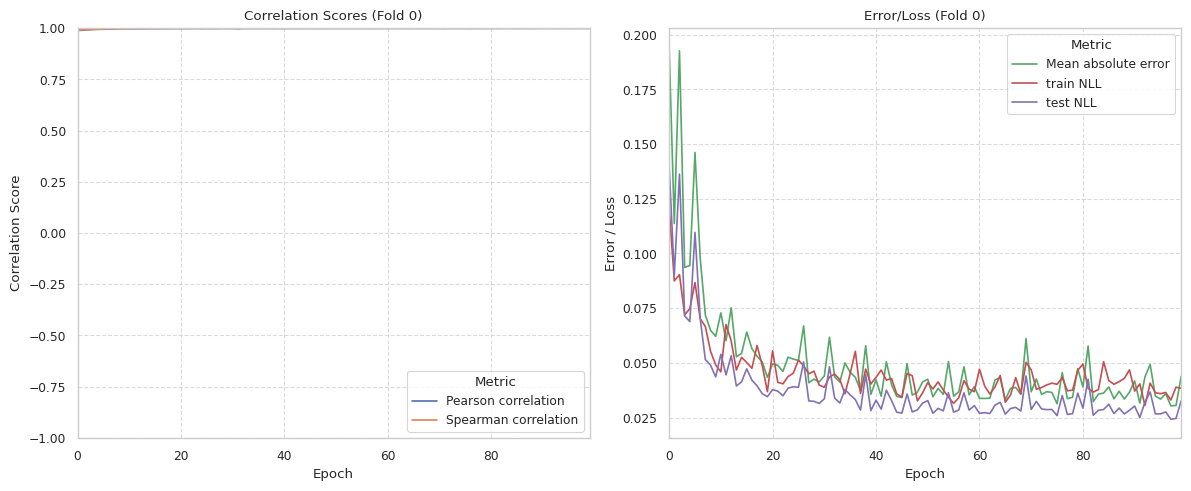

  Saved plot: trained_models/test-100e-ms-pw-stations-mean-4/trainingstats_fold1


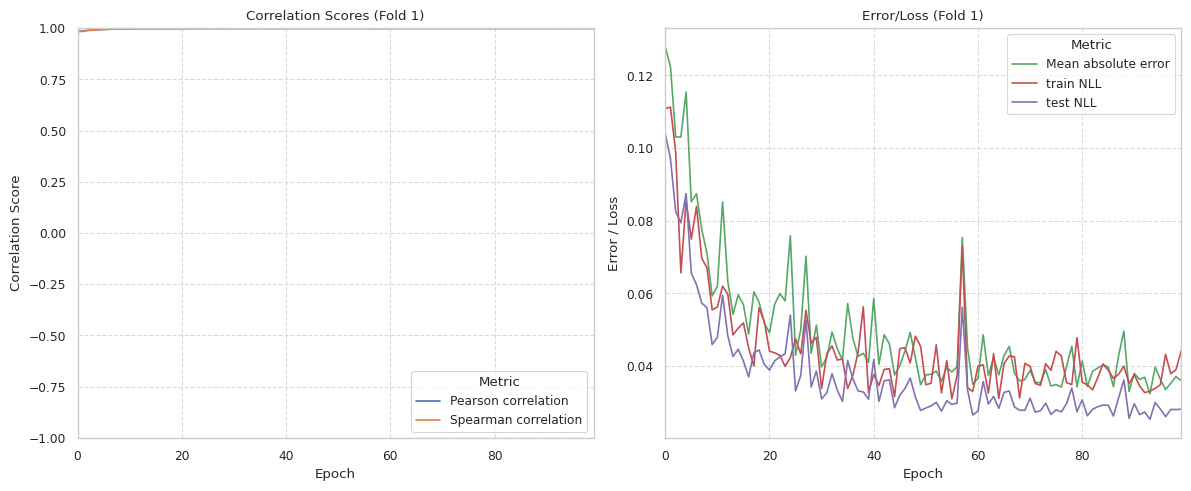

  Saved plot: trained_models/test-100e-ms-pw-stations-mean-4/trainingstats_fold2


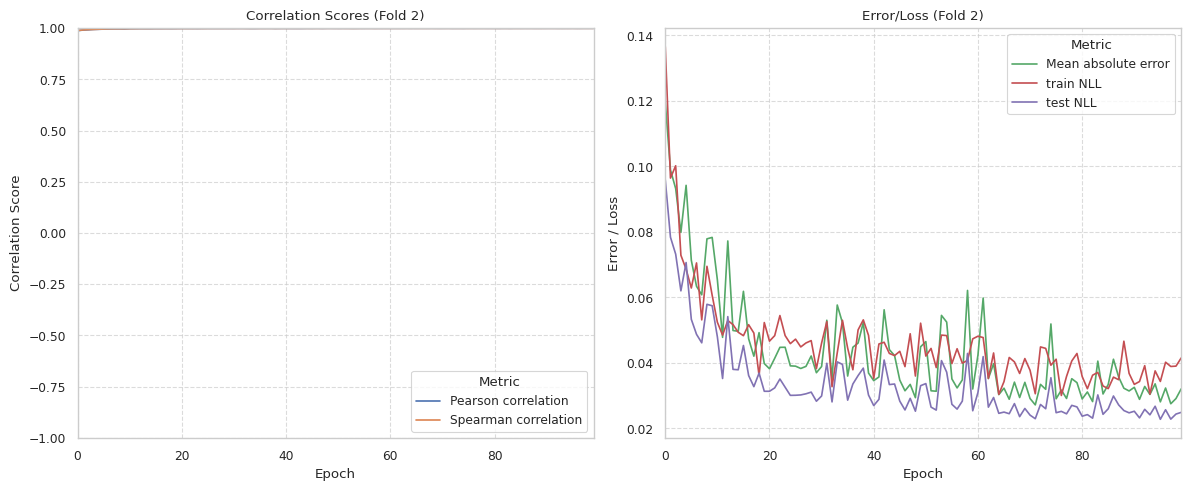

  Saved plot: trained_models/test-100e-ms-pw-stations-mean-4/trainingstats_fold3


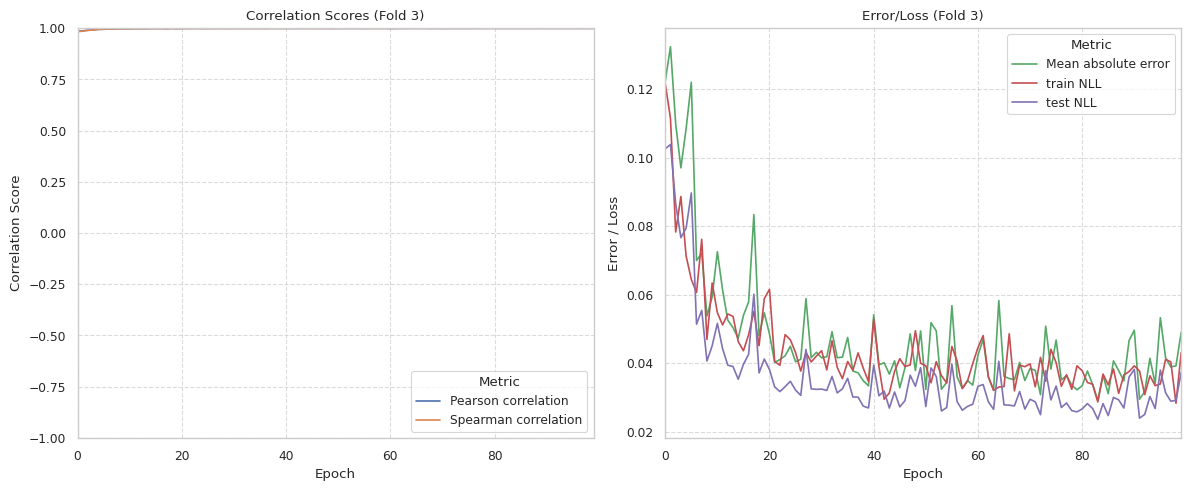

  Saved plot: trained_models/test-100e-ms-pw-stations-mean-4/trainingstats_fold4


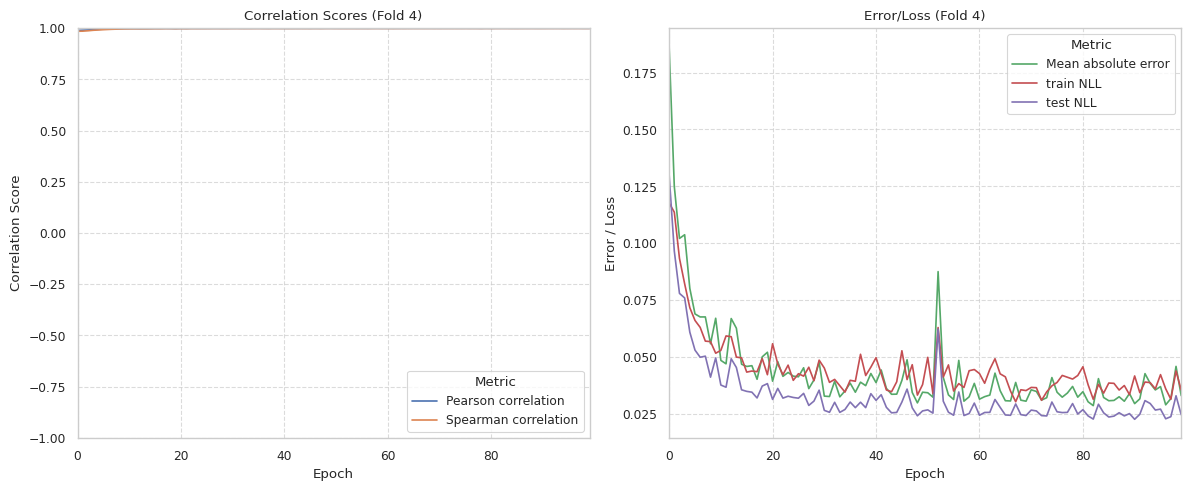

  Saved plot: trained_models/test-100e-ms-pw-stations-mean-4/trainingstats_all


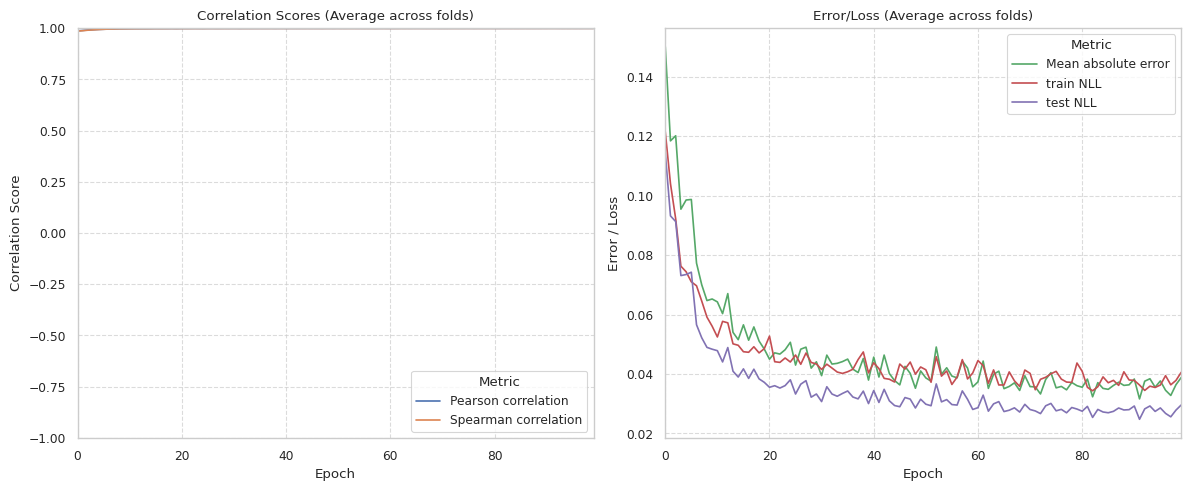

In [17]:
save_path_prefix = str(OUTPUT_DIR / 'trainingstats')
vis.plot_training_curves(stats, save_path=save_path_prefix)
plt.show()